In [1]:
import pandas as pd
import numpy as np
import ast
from pathlib import Path

cwd = Path.cwd()
CSV_PATH = cwd.parent.parent / "tests" / "architecture_comparisons_tests.csv"

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df.head(5)

,trial_num,total_epochs,split_seed,trial_seed,total_parameters,hidden_layer_sizes,dropout_size,has_batch_normalization,epoch_list,train_MSE,test_MSE,train_RMSE,test_RMSE,train_r2_score,test_r2_score,train_y,train_model_y,test_y,test_model_y
0,1,10000,42,715,3955,"[2, 4, 16, 32, 16]",0.0,False,"[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,...","[0.024645362049341202, 0.023095080628991127, 0...","[0.026181232184171677, 0.02462456189095974, 0....","[0.15698841374235617, 0.15197065713153685, 0.1...","[0.1618061561998544, 0.15692215232706866, 0.15...","[0.6473705768585205, 0.669552206993103, 0.6719...","[0.6556129455566406, 0.6760892868041992, 0.678...","[0.28060001134872437, 0.3165999948978424, 0.00...","[0.26124435663223267, 0.3036109209060669, -0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.6922478675842285, 0.03444461524486542, 0.47..."
1,2,10000,42,715,3955,"[2, 4, 16, 32, 16]",0.2,False,"[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,...","[0.019102366641163826, 0.012631412595510483, 0...","[0.02113504894077778, 0.013368500396609306, 0....","[0.1382113115528676, 0.11238955732411478, 0.09...","[0.1453789838345893, 0.1156222314116507, 0.101...","[0.7266805768013, 0.8192679286003113, 0.861702...","[0.7219902276992798, 0.8241511583328247, 0.865...","[0.28060001134872437, 0.3165999948978424, 0.00...","[0.29754114151000977, 0.28257545828819275, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8365211486816406, 0.06974342465400696, 0.21..."
2,3,10000,42,715,4095,"[2, 4, 16, 32, 16]",0.0,True,"[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,...","[0.07969505339860916, 0.09086385369300842, 0.1...","[0.08576910197734833, 0.09709816426038742, 0.1...","[0.2823031232533731, 0.30143631780694313, 0.35...","[0.29286362351331435, 0.3116057834193509, 0.35...","[-0.14028847217559814, -0.3000931739807129, -0...","[-0.12820398807525635, -0.27722620964050293, -...","[0.28060001134872437, 0.3165999948978424, 0.00...","[0.25997841358184814, 0.21522748470306396, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.2461727112531662, 0.06521716713905334, 0.11..."
3,4,10000,42,715,4095,"[2, 4, 16, 32, 16]",0.2,True,"[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,...","[0.06976260244846344, 0.07746905833482742, 0.0...","[0.07736160606145859, 0.0846598893404007, 0.07...","[0.26412611087975274, 0.27833263972237865, 0.2...","[0.2781395442245827, 0.2909637251280659, 0.280...","[0.0018265843391418457, -0.10843849182128906, ...","[-0.017612099647521973, -0.11361348628997803, ...","[0.28060001134872437, 0.3165999948978424, 0.00...","[0.14155994355678558, 0.06988826394081116, 0.0...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.14979910850524902, 0.061939820647239685, 0...."
4,5,10000,42,715,4715,"[2, 4, 8, 32, 32, 16]",0.0,False,"[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110,...","[0.013609657995402813, 0.008756930939853191, 0...","[0.014318660832941532, 0.008923017419874668, 0...","[0.11666043886169301, 0.09357847476772205, 0.0...","[0.11966060685514482, 0.09446172462894518, 0.0...","[0.8052710294723511, 0.8747045993804932, 0.901...","[0.8116527795791626, 0.8826268911361694, 0.910...","[0.28060001134872437, 0.3165999948978424, 0.00...","[0.2441841959953308, 0.31828466057777405, 0.03...","[0.7901999950408936, 0.0538799986243248, 0.253...","[0.8045382499694824, 0.032556235790252686, 0.2..."


In [3]:
def string_to_float_array_safe(x):
    # leave non-strings alone
    if not isinstance(x, str):
        return x
    
    s = x.strip()
    # only try parsing obvious list/tuple literals
    if not (s.startswith("[") or s.startswith("(")):
        return x
    
    try:
        val = ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return x  # not a valid literal
    
    # Only convert list/tuple-like things
    if isinstance(val, (list, tuple)):
        return np.asarray(val, dtype=float)
    return x

In [4]:
df = df.apply(lambda col: col.map(string_to_float_array_safe))

In [5]:
import matplotlib.pyplot as plt

In [6]:
def plot_metric(df, metric):
    if metric not in ['MSE', 'RMSE', 'R2']:
        print(f"Error, {metric} not in {['MSE', 'RMSE', 'R2']}")
        return
        
    fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
    axes = np.atleast_2d(axes)

    metric_map = {
        "MSE": ('train_MSE', 'test_MSE'),
        "RMSE": ('train_RMSE', 'test_RMSE'),
        "R2": ('train_r2_score', 'test_r2_score')
    }

    train_metric, test_metric = metric_map[metric]
    
    for i, row in df.reset_index(drop=True).iterrows():
        x = np.asarray(row["epoch_list"], dtype=float)
        y_tr = np.asarray(row[train_metric], dtype=float)
        y_te = np.asarray(row[test_metric], dtype=float)
    
        axes[i, 0].plot(x, y_tr, alpha=0.8)
        axes[i, 0].set_title(f'Train {metric} - Total Parameters: {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normalization"] else "False"} - (trial {row["trial_num"]})')
        axes[i, 0].set_xlabel(r"Number of Epochs")
        axes[i, 0].set_ylabel(f"{metric}")
    
        axes[i, 1].plot(x, y_te, alpha=0.8)
        axes[i, 1].set_title(f'Test {metric} - Total Parameters: {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normalization"] else "False"} (trial {row["trial_num"]})')
        axes[i, 1].set_xlabel(r"Number of Epochs")
        axes[i, 1].set_ylabel(f"{metric}")
    
    plt.tight_layout()
    plt.show()

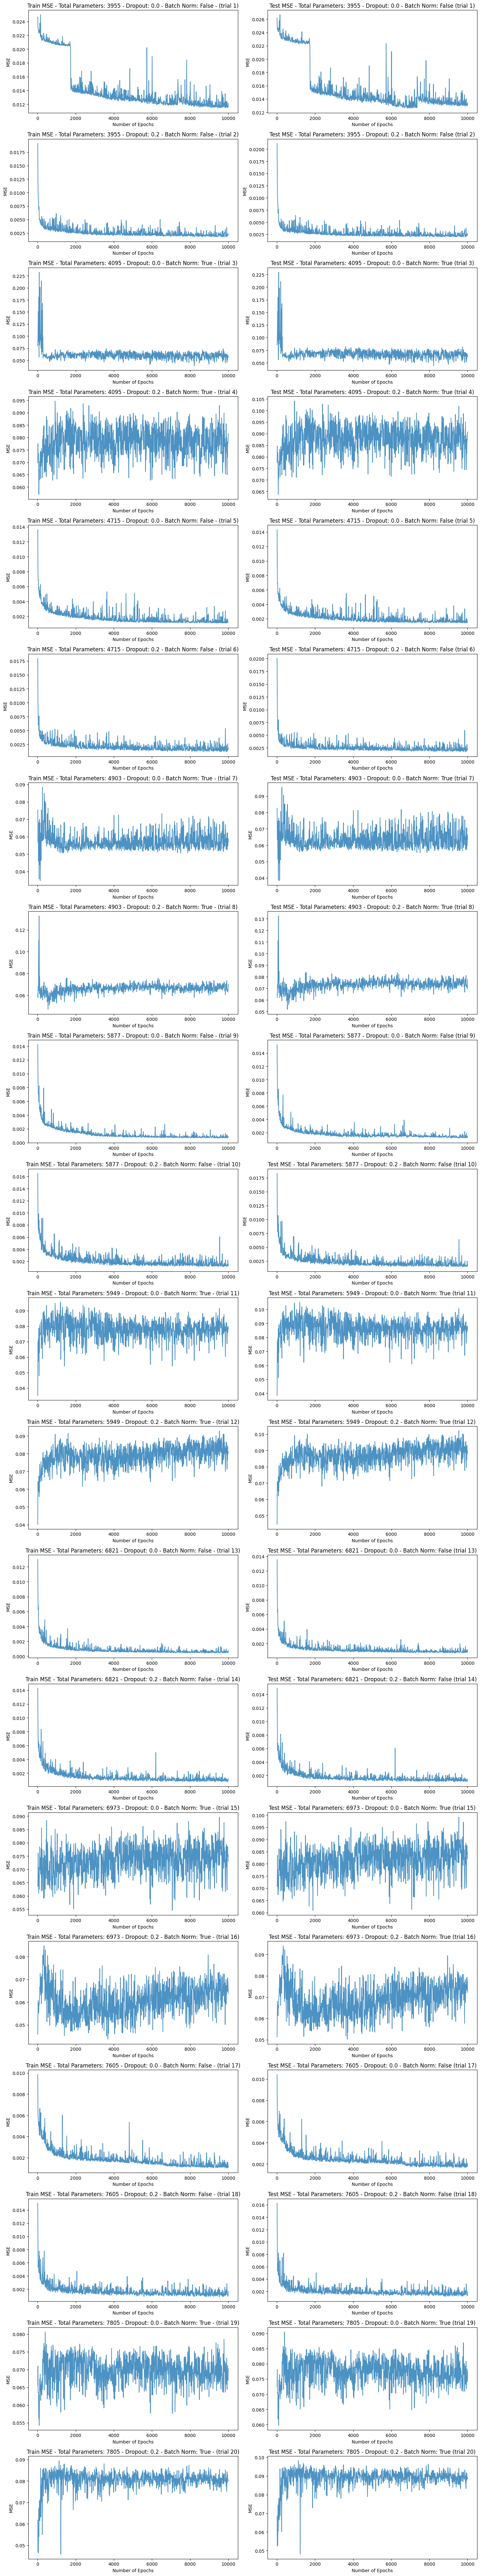

In [7]:
# MSE, RMSE, R2
plot_metric(df, 'MSE')

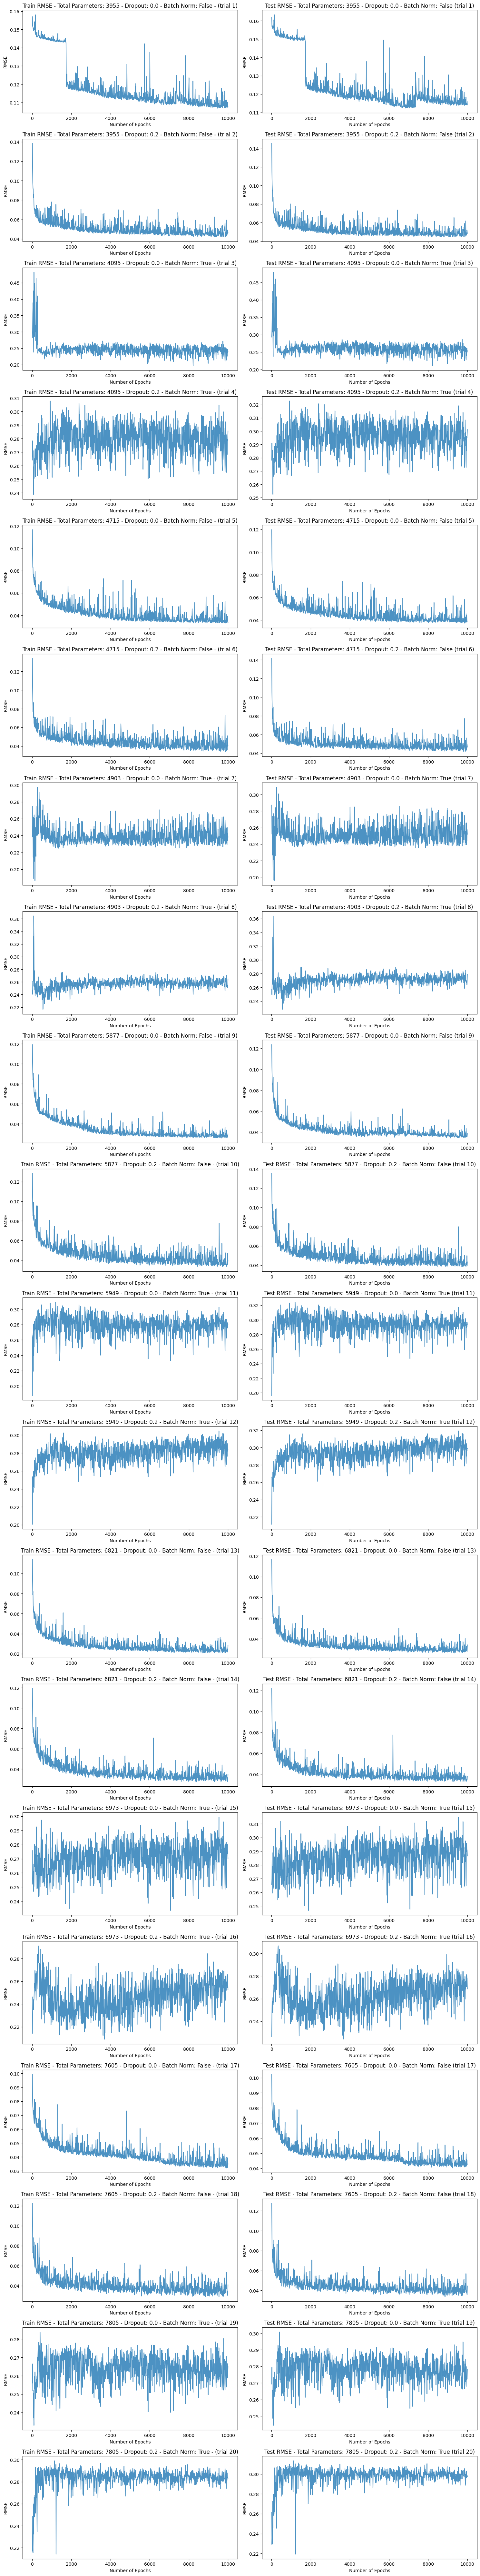

In [8]:
plot_metric(df, 'RMSE')

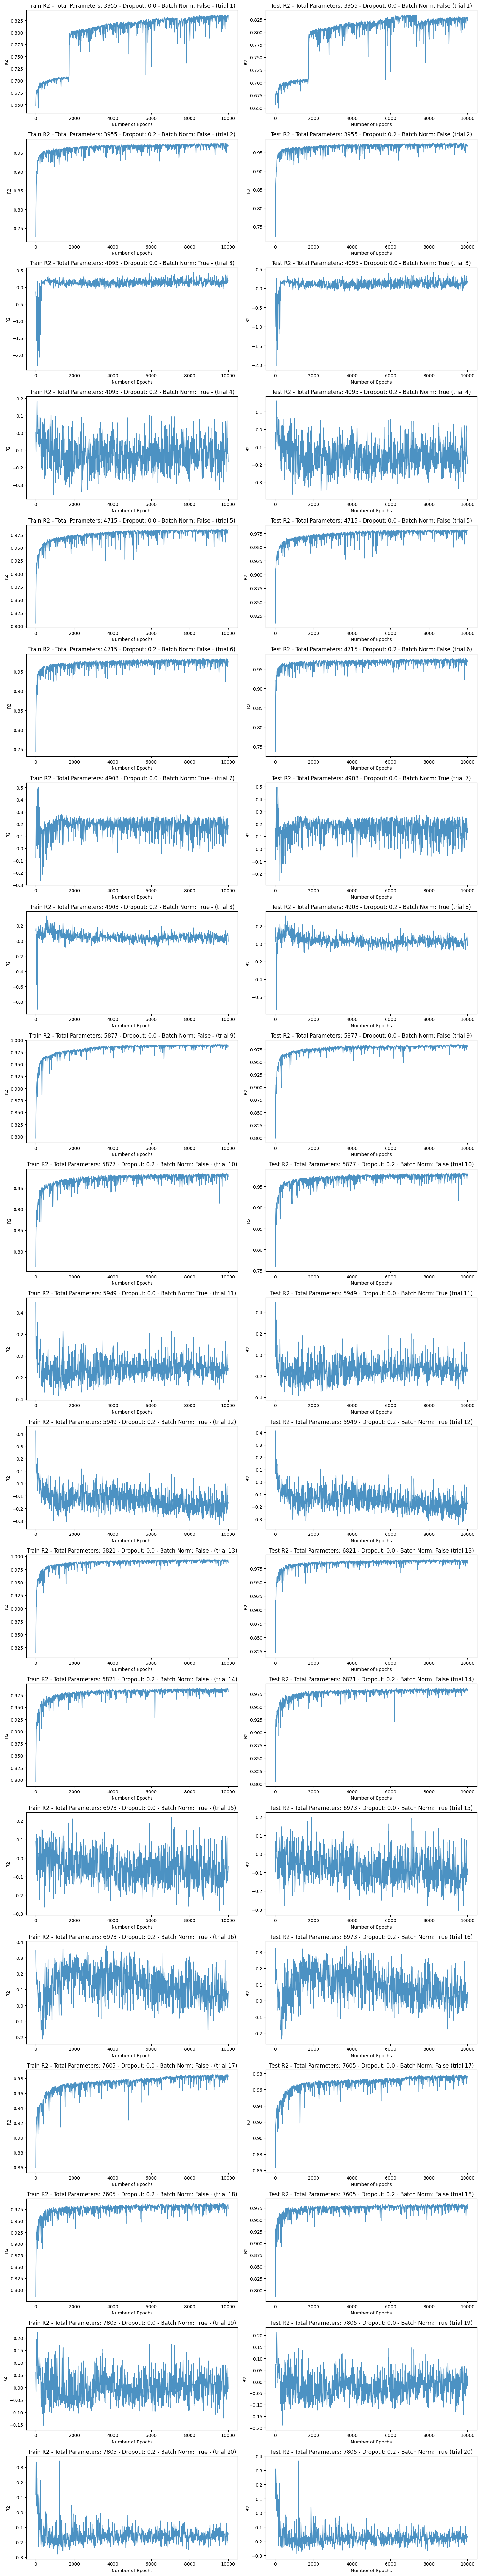

In [9]:
plot_metric(df, 'R2')

In [10]:
selected_trial_num = 13

trial_test_R2_scores = df.iloc[selected_trial_num-1, :]['test_r2_score']
last_50_trial_test_R2 = trial_test_R2_scores[len(trial_test_R2_scores)-5:]
print(f"Average R2 for trial {selected_trial_num}: {str(round((sum(last_50_trial_test_R2)/len(last_50_trial_test_R2)), 4))}")

trial_test_MSE = df.iloc[selected_trial_num-1, :]['test_MSE']
last_50_trial_test_MSE = trial_test_MSE[len(trial_test_MSE)-5:]
avg_test_MSE = sum(last_50_trial_test_MSE)/len(last_50_trial_test_MSE)
print(f"Average MSE for trial {selected_trial_num}: {avg_test_MSE:.3g}")

trial_test_RMSE = df.iloc[selected_trial_num-1, :]['test_RMSE']
last_50_trial_test_RMSE = trial_test_RMSE[len(trial_test_RMSE)-5:]
print(f"Average RMSE for trial {selected_trial_num}: {str(round((sum(last_50_trial_test_RMSE)/len(last_50_trial_test_RMSE)*1000), 3))}nm")

Average R2 for trial 13: 0.9883
Average MSE for trial 13: 0.000886
Average RMSE for trial 13: 29.67nm


In [11]:
def plot_scatter_with_fit(ax, x, y):
    # Scatter
    ax.scatter(x, y, s=10, alpha=0.6)

    # Regression line (least squares)
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m*xx + b, color="red", linestyle="--", linewidth=2, label=f"fit: y={m:.2f}x+{b:.2f}")

    # y = x reference line
    ax.plot(xx, xx, color="black", linewidth=1, alpha=0.6, label="ideal: y=x")

    ax.legend()

In [12]:
def plot_related(df):
    fig, axes = plt.subplots(len(df), 2, figsize=(15, 4*len(df)))
    axes = np.atleast_2d(axes)
    
    for i, row in df.reset_index(drop=True).iterrows():
        x_tr = np.asarray(row["train_y"], dtype=float)
        y_tr = np.asarray(row["train_model_y"], dtype=float)
        x_te = np.asarray(row["test_y"], dtype=float)
        y_te = np.asarray(row["test_model_y"], dtype=float)
    
        plot_scatter_with_fit(axes[i, 0], x_tr, y_tr)
        axes[i, 0].set_title(f'Parameters: {row["hidden_layer_sizes"]} = {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normalization"] else "False"} (trial {row["trial_num"]})')
        axes[i, 0].set_xlabel(r"Train y ($\mu$m)")
        axes[i, 0].set_ylabel(r"Model Train y ($\mu$m)")
    
        plot_scatter_with_fit(axes[i, 1], x_te, y_te)
        axes[i, 1].set_title(f'Parameters: {row["hidden_layer_sizes"]} = {row["total_parameters"]} - Dropout: {row["dropout_size"]} - Batch Norm: {"True" if row["has_batch_normalization"] else "False"} (trial {row["trial_num"]})')
        axes[i, 1].set_xlabel(r"Test y ($\mu$m)")
        axes[i, 1].set_ylabel(r"Model Test y ($\mu$m)")
    
    plt.tight_layout()
    plt.show()

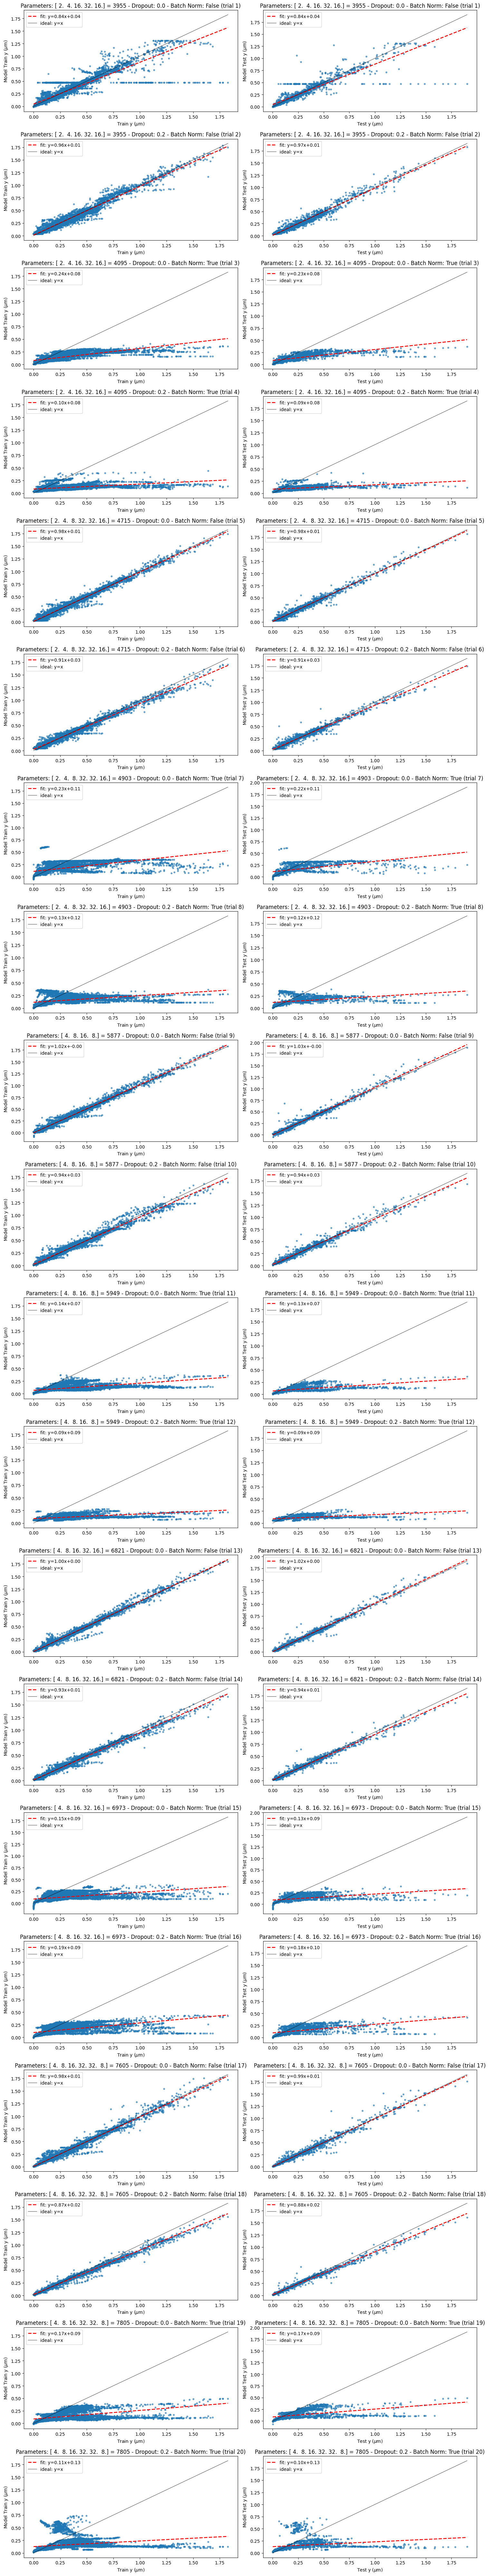

In [13]:
# 10000 epochs
plot_related(df)

In [14]:
results = []

for i in range(len(df)):
    row = df.iloc[i]
    
    # Calculate averages from the lists in the row
    last5_r2   = row['test_r2_score'][-5:]
    last5_mse  = row['test_MSE'][-5:]
    last5_rmse = row['test_RMSE'][-5:]
    
    avg_r2   = sum(last5_r2) / len(last5_r2)
    avg_mse  = sum(last5_mse) / len(last5_mse)
    avg_rmse = (sum(last5_rmse) / len(last5_rmse)) * 1000  # in nm
    
    results.append({
        'Hidden Layers':           str(row['hidden_layer_sizes']),
        'Parameters':              int(row['total_parameters']),
        'Trial':                   int(row['trial_num']),
        'Has Dropout (0.2)':       "Yes" if row['dropout_size'] == 0.2 else "No",
        'Has Batch Norm':          "Yes" if bool(row['has_batch_normalization']) else "No",
        'R2':                      avg_r2,
        'MSE':                     avg_mse,
        'RMSE (nm)':               avg_rmse,
    })

In [15]:
summary_df = pd.DataFrame(results)

# 1. Reorder columns so 'Trial' is first
cols = ['Trial', 'Hidden Layers', 'Parameters', 'Has Dropout (0.2)', 'Has Batch Norm', 'R2', 'MSE', 'RMSE (nm)']
summary_df = summary_df[cols]

# 2. Sort the data
# We still sort by Layers/Params so the "merging" logic works visually
summary_df = summary_df.sort_values(['Trial', 'Hidden Layers', 'Parameters',])

# 3. Create display version and mask duplicates
display_df = summary_df.copy()
display_df['Hidden Layers'] = display_df['Hidden Layers'].mask(display_df['Hidden Layers'].duplicated(), "")
display_df['Parameters'] = display_df['Parameters'].mask(
    (display_df['Parameters'].duplicated()) & (display_df['Hidden Layers'] == ""), 
    ""
)

# 4. Style the DataFrame
styled_df = display_df.style.format({
    'R2': "{:.4f}",
    'MSE': "{:.3g}",
    'RMSE (nm)': "{:.2f}"
}).hide(axis='index')

# 5. Apply the alignment styles
styled_df.set_table_styles([
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('vertical-align', 'middle'),
        ('background-color', '#f2f2f2'),
        ('padding', '10px 15px'),
        ('border', '1px solid #ccc'),
        ('font-weight', 'bold')
    ]},
    {'selector': 'td', 'props': [
        ('text-align', 'center'), 
        ('padding', '8px'),
        ('border', '1px solid #eee')
    ]}
])

styled_df

Trial,Hidden Layers,Parameters,Has Dropout (0.2),Has Batch Norm,R2,MSE,RMSE (nm)
1,[ 2. 4. 16. 32. 16.],3955,No,No,0.8268,0.0132,114.75
2,,,Yes,No,0.9678,0.00245,49.43
3,,4095,No,Yes,0.1588,0.064,252.76
4,,,Yes,Yes,-0.1434,0.0869,294.78
5,[ 2. 4. 8. 32. 32. 16.],4715,No,No,0.9784,0.00164,40.44
6,,,Yes,No,0.9690,0.00235,48.32
7,,4903,No,Yes,0.1593,0.0639,252.67
8,,,Yes,Yes,0.0479,0.0724,268.99
9,[ 4. 8. 16. 8.],5877,No,No,0.9828,0.00131,36.12
10,,,Yes,No,0.9757,0.00185,42.84
